## LAB 04 : DECISION TREE CLASSIFIER

- NAME : MUHAMMAD FASIH
- ROLL NO : 24F-AI-016


## Task 1: Load Dataset 
- Use a dataset such as Iris dataset (from sklearn) or load any CSV file. 

In [2]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target


df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Task 2: Exploratory Data Analysis (EDA)
- Display dataset information, shape, and statistical summary.
- Plot distributions of features (histograms / pairplot). 
- Visualize correlations 





In [3]:
import seaborn as sns

import matplotlib.pyplot as plt

# Dataset information
print("Dataset shape:", df.shape)
df.info()

print("\nStatistical summary:")
display(df.describe())




Dataset shape: (150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Statistical summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


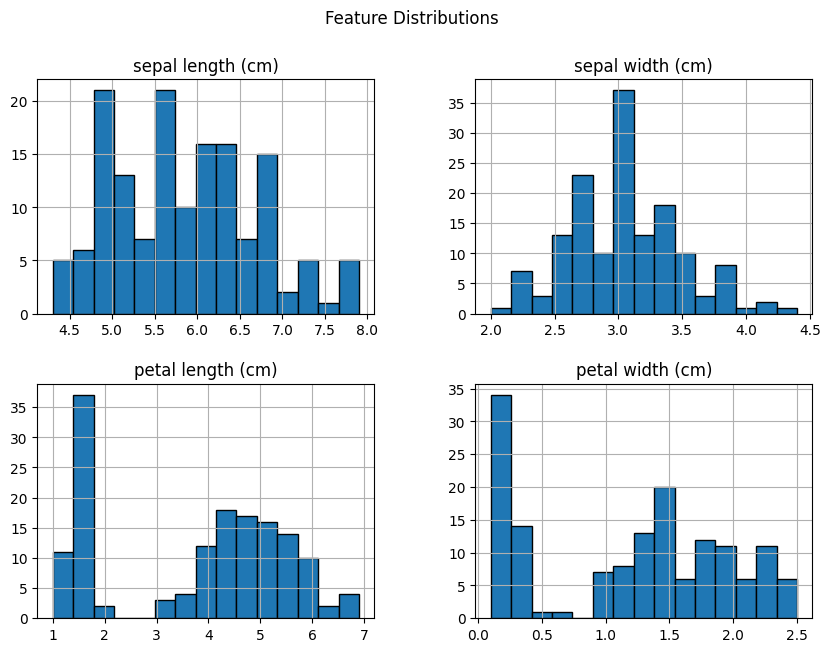

In [4]:
# Feature distributions
feature_columns = iris.feature_names

df[feature_columns].hist(figsize=(10, 7), bins=15, edgecolor="black")
plt.suptitle("Feature Distributions")

plt.show()



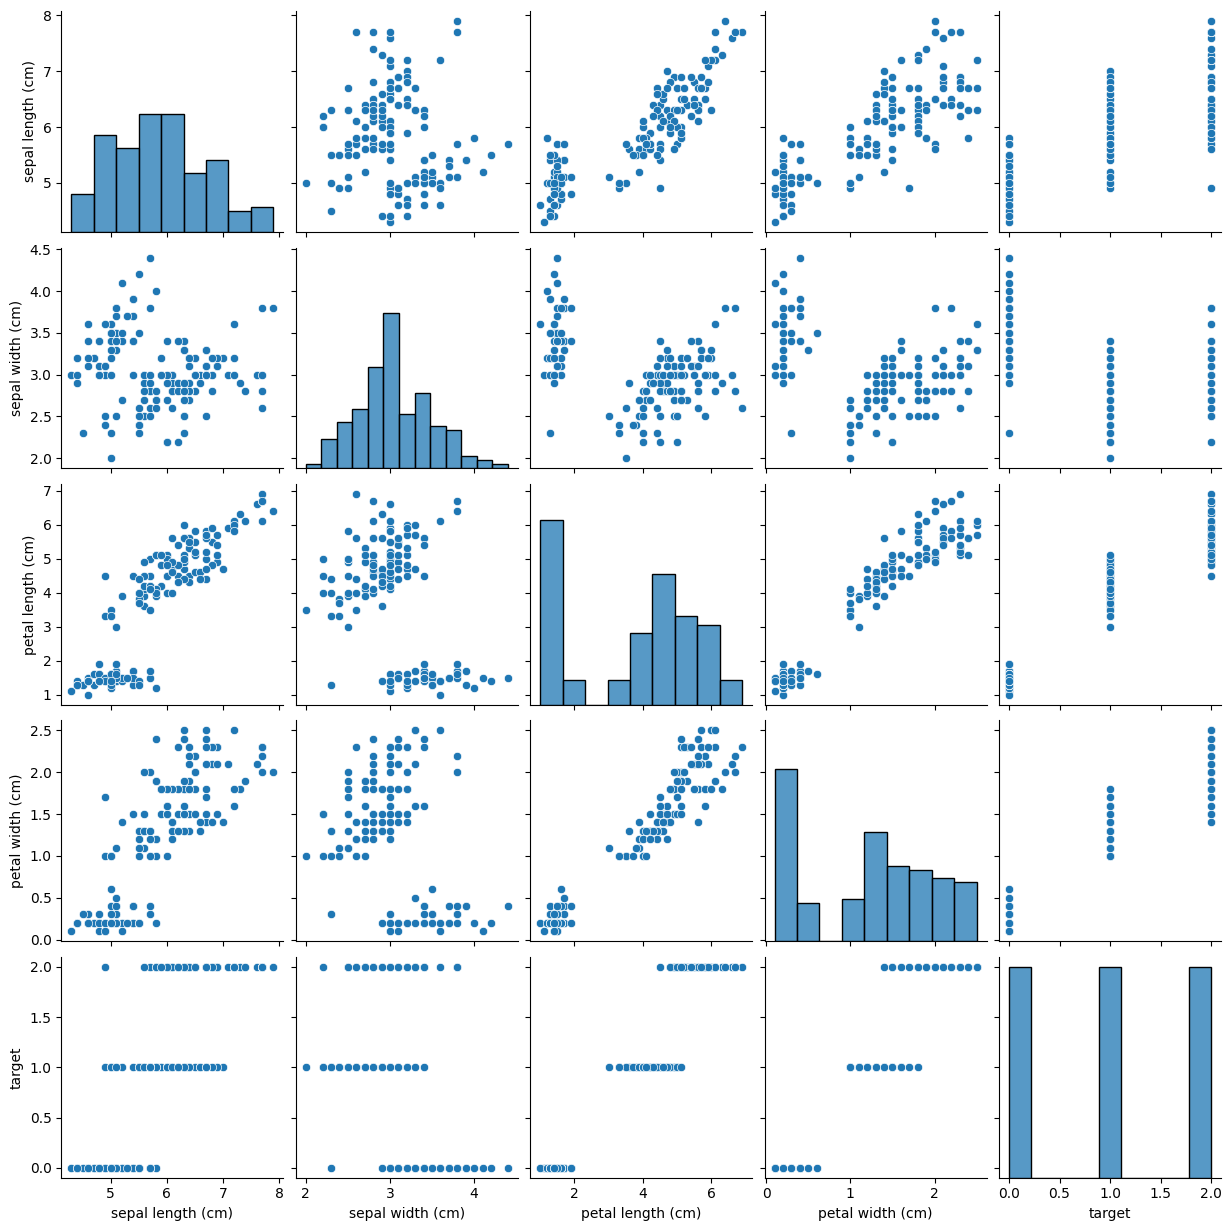

In [5]:
# Pairplot
sns.pairplot(df)
plt.show()



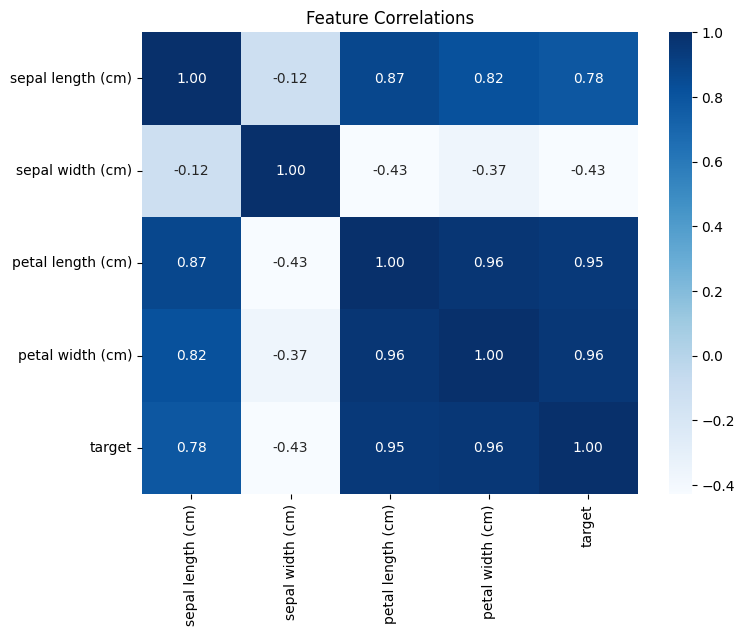

In [6]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)
plt.title("Feature Correlations")
plt.show()

## Task 3: Data Preprocessing 
- Split dataset into training and testing sets (e.g., 70% train, 30% test). 

In [7]:
from sklearn.model_selection import train_test_split

X = df[feature_columns]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
	X, y,
	test_size=0.30,
	random_state=42,
)



## Task 4: Build Decision Tree Classifier
- Train the model using DecisionTreeClassifier. 

In [8]:
from sklearn.tree import DecisionTreeClassifier

dfc = DecisionTreeClassifier()

dfc.fit(X_train, y_train)

y_pred = dfc.predict(X_test)


In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)



Accuracy: 1.0


In [10]:
print("Classification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [11]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


### Task 5: Model Evaluation


• Make predictions on the test data.


In [12]:
# Make predictions on the test data
y_pred = dfc.predict(X_test)

print("Predicted labels:")
print(y_pred)

print("\nActual labels:")
print(y_test.values)

Predicted labels:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]

Actual labels:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]


### Evaluate using:
- Accuracy Score
- Confusion Matrix
- Classification Report

- Accuracy Score

In [13]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)


Accuracy Score: 1.0


- Confusion Matrix

Confusion Matrix:


,setosa,versicolor,virginica
setosa,19,0,0
versicolor,0,13,0
virginica,0,0,13


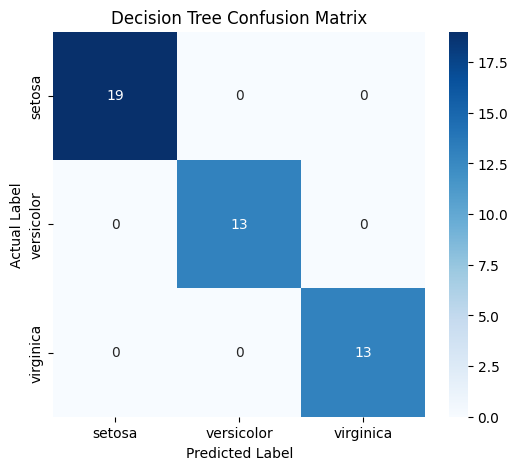

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
cm_df = pd.DataFrame(cm, index=iris.target_names, columns=iris.target_names)

print("Confusion Matrix:")
display(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

- Classification Report

In [15]:
# Classification Report
report = classification_report(y_test, y_pred, target_names=iris.target_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print("Classification Report:")
display(report_df)

Classification Report:


,precision,recall,f1-score,support
setosa,1.0,1.0,1.0,19.0
versicolor,1.0,1.0,1.0,13.0
virginica,1.0,1.0,1.0,13.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,45.0
weighted avg,1.0,1.0,1.0,45.0


### Task 6: Experimentation
• Change parameters (criterion = "gini" vs "entropy", max_depth, min_samples_split).



In [18]:
import numpy as np

criteria = np.array(["gini", "entropy"])
depths = np.array([None, 3, 5], dtype=object)
split_sizes = np.array([2, 5])

experiment_results = []

for criterion_value in criteria:
    for depth in depths:
        for split_size in split_sizes:
            experiment_model = DecisionTreeClassifier(
                criterion=criterion_value,
                max_depth=depth,
                min_samples_split=split_size,
                random_state=42
            )
            experiment_model.fit(X_train, y_train)
            score = accuracy_score(y_test, experiment_model.predict(X_test))

            experiment_results.append({
                "criterion": criterion_value,
                "max_depth": depth,
                "min_samples_split": split_size,
                "accuracy": score
            })

experiment_df = pd.DataFrame(experiment_results)
display(experiment_df)


,criterion,max_depth,min_samples_split,accuracy
0,gini,NaN,2,1.000000
1,gini,NaN,5,1.000000
2,gini,3.0,2,1.000000
3,gini,3.0,5,1.000000
4,gini,5.0,2,1.000000
5,gini,5.0,5,1.000000
6,entropy,NaN,2,0.977778
7,entropy,NaN,5,0.977778
8,entropy,3.0,2,0.977778
9,entropy,3.0,5,0.977778


• Compare results and observe overfitting vs underfitting.


In [19]:
# Compare model performance and identify overfitting / underfitting patterns
comparison_rows = []

for criterion_value in ["gini", "entropy"]:
    for depth in [None, 3, 5]:
        for split_size in [2, 5]:
            model = DecisionTreeClassifier(
                criterion=criterion_value,
                max_depth=depth,
                min_samples_split=split_size,
                random_state=42
            )
            model.fit(X_train, y_train)

            train_pred = model.predict(X_train)
            test_pred = model.predict(X_test)

            train_acc = accuracy_score(y_train, train_pred)
            test_acc = accuracy_score(y_test, test_pred)
            gap = train_acc - test_acc

            comparison_rows.append({
                "criterion": criterion_value,
                "max_depth": depth,
                "min_samples_split": split_size,
                "train_accuracy": train_acc,
                "test_accuracy": test_acc,
                "gap": gap
            })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(["criterion", "max_depth", "min_samples_split"]).reset_index(drop=True)
display(comparison_df)

print("\nBest model based on test accuracy:")
display(comparison_df.sort_values("test_accuracy", ascending=False).head(1))

print("\nMost overfitted models (largest train-test accuracy gap):")
display(comparison_df.sort_values("gap", ascending=False).head(5))

# Observations
print("\nInterpretation:")
print("- Overfitting: train_accuracy is much higher than test_accuracy, meaning the model memorizes the training data.")
print("- Underfitting: both train_accuracy and test_accuracy are low, meaning the model is too simple to learn the pattern.")
print("- Good fit: both accuracies are high and close to each other.")

,criterion,max_depth,min_samples_split,train_accuracy,test_accuracy,gap
0,entropy,3.0,2,0.952381,0.977778,-0.025397
1,entropy,3.0,5,0.952381,0.977778,-0.025397
2,entropy,5.0,2,0.990476,0.977778,0.012698
3,entropy,5.0,5,0.990476,0.977778,0.012698
4,entropy,NaN,2,1.000000,0.977778,0.022222
5,entropy,NaN,5,0.990476,0.977778,0.012698
6,gini,3.0,2,0.952381,1.000000,-0.047619
7,gini,3.0,5,0.952381,1.000000,-0.047619
8,gini,5.0,2,0.990476,1.000000,-0.009524
9,gini,5.0,5,0.980952,1.000000,-0.019048



Best model based on test accuracy:


,criterion,max_depth,min_samples_split,train_accuracy,test_accuracy,gap
8,gini,5.0,2,0.990476,1.0,-0.009524



Most overfitted models (largest train-test accuracy gap):


,criterion,max_depth,min_samples_split,train_accuracy,test_accuracy,gap
4,entropy,NaN,2,1.000000,0.977778,0.022222
3,entropy,5.0,5,0.990476,0.977778,0.012698
5,entropy,NaN,5,0.990476,0.977778,0.012698
2,entropy,5.0,2,0.990476,0.977778,0.012698
10,gini,NaN,2,1.000000,1.000000,0.000000



Interpretation:
- Overfitting: train_accuracy is much higher than test_accuracy, meaning the model memorizes the training data.
- Underfitting: both train_accuracy and test_accuracy are low, meaning the model is too simple to learn the pattern.
- Good fit: both accuracies are high and close to each other.
